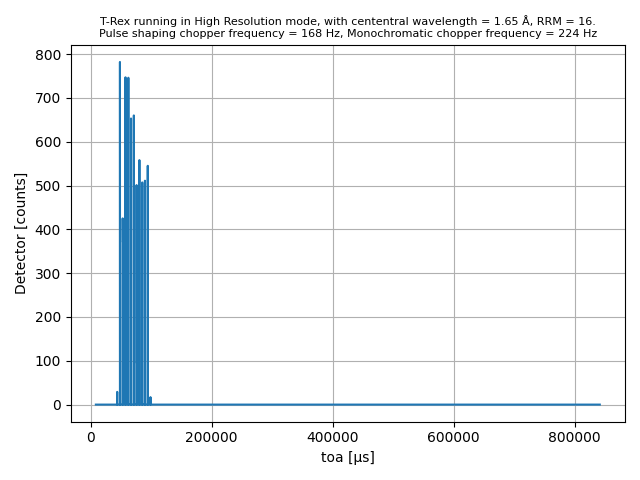

In [32]:
%matplotlib widget
import scipp as sc
from trex.instrument import Instrument
from trex.source import Source
import plopp as pp
import matplotlib.pylab as plt

central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source=Source(facility="ess", neutrons=10_000_000,)
wavelength_requested = trex.calculate_incoming_wavelength()
res = trex.model.run()

hist_det = res.detectors["Detector"].data.hist(toa=5_000)


fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

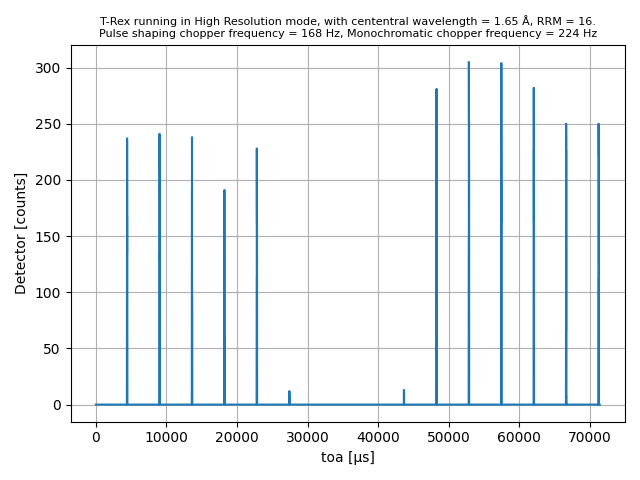

In [33]:
trex.wrap_frame(res)
hist_det = res.detectors["Detector"].data.hist(toa=5_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

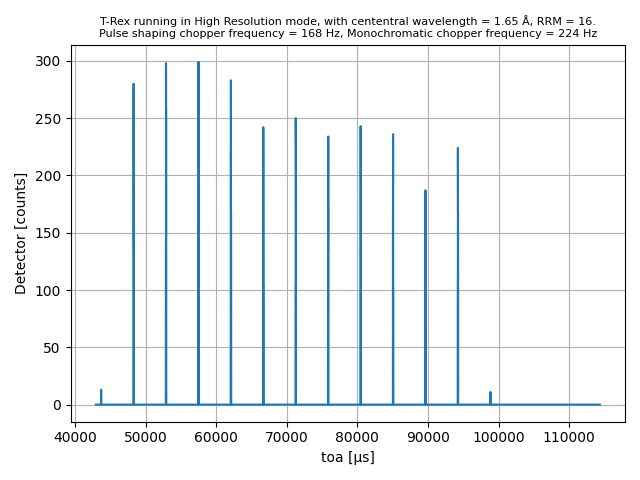

In [34]:
reduced_list = trex.unwrap_frame(res)
hist_det = res.detectors["Detector"].data.hist(toa=5_000)

fig, ax = plt.subplots()
p = pp.plot({"Detector": hist_det}, grid=True, ax=ax)  # type: ignore
ax.set_title(str(trex), fontsize=8)
fig.tight_layout()

In [35]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(en=sc.arange('en',-8,8,0.1,unit='meV'))
    for reduced in reduced_list
}

p= pp.plot(hist_dict, marker='o', grid=True, markersize=4,linestyle='-')
p.ax.set_title(str(trex),fontsize=8)
p

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [36]:
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(ef=sc.arange('ef',10,100,0.1,unit='meV'))
    for reduced in reduced_list
}
p=pp.plot(hist_dict, marker='o', grid=True, markersize=4,linestyle='-',figsize=(12,6))
p.ax.set_title(str(trex),fontsize=8)
p

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…